Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Split the data ine training and testing
Data scalled for traing and testing
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3495 - loss: 0.6636 - val_accuracy: 0.5238 - val_loss: 0.7549
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4074 - loss: 0.7296 - val_accuracy: 0.5119 - val_loss: 0.7328
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4471 - loss: 0.7440 - val_accuracy: 0.5476 - val_loss: 0.7155
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5035 - loss: 0.6615 - val_accuracy: 0.6310 - val_loss: 0.6976
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5150 - loss: 0.7233 - val_accuracy: 0.6548 - val_loss: 0.6942
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5721 - loss: 0.6520 - val_accuracy: 0.6548 - val_loss: 0.6834
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6413 - loss: 0.7049 - val_accuracy: 0.6786 - val_loss: 0.6792
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6728 - loss: 0.6590 - val_accuracy: 0.7143 - val_loss: 0.6663
Ep

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Y prediction: [[1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]]

Test Accuracy: 0.31666666666666665

Classific

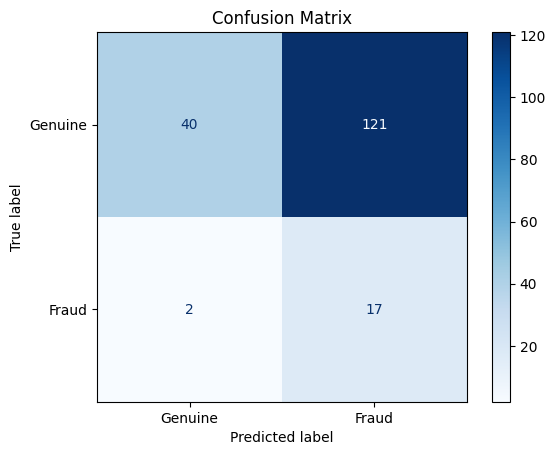

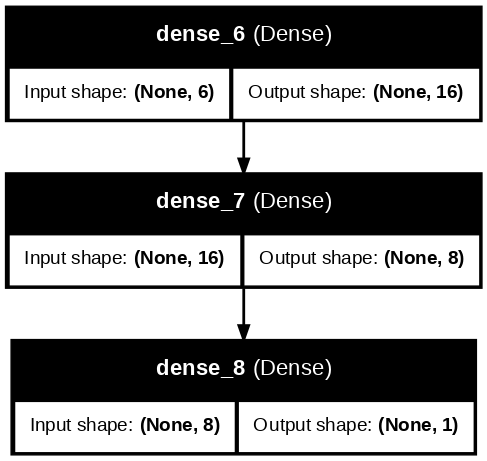

In [ ]:
%pip install pandas openpyxl
import pandas as pd 
from google.colab import drive
from pathlib import  Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import Image, display

drive.mount('/content/drive')
base_path_file = Path('/content/drive/MyDrive/GenerativeAI')
file_url = base_path_file / "fraud_detection_training_data.xlsx"

df = pd.read_excel(file_url)

#print(f"File content is {df}")

label_encoder = LabelEncoder()
df["MerchantCategory"] = label_encoder.fit_transform(df["MerchantCategory"])
df['TransactionTime'] = pd.to_datetime(df['TransactionTime'], format='%H:%M').dt.hour * 60 + \
                     pd.to_datetime(df['TransactionTime'], format='%H:%M').dt.minute

x = df[["TransactionAmount","TransactionTime", "MerchantCategory", "CustomerAge", "AccountBalance", "NumberOfTransactionsToday"]]
y = df["Fraud"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state = 42)

print(f"Split the data ine training and testing")
stander_scale = StandardScaler()
x_train_scaled = stander_scale.fit_transform(x_train)
x_test_scaled = stander_scale.transform(x_test)
print(f"Data scalled for traing and testing")

#This creates a neural network model using the Sequential method.
#In a dense layer, every neuron connects to every neuron in the previous layer. 16 is the number of neurons, ReLU activation function to each neuron, Without an activation function, the neural network becomes just a simple linear model. ReLU helps the network learn nonlinear patterns.
# input_shape: This tells the model:each training example has 6 input valu
# Sigmoid converts the output into a value between 0 and 1.
#6 input features -> Hidden layer with 16 neurons + ReLU -> Hidden layer with 8 neurons + ReLU -> output neuron + Sigmoid -> Fraud probability
model = Sequential([
    Dense(16, activation='relu', input_shape=(6,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
#The optimizer controls how the model updates its weights during learning.
#loss='binary_crossentropy' : how to measure prediction error.
model.compile(optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

#train the model, using x and y data, Epoch: how many times model will go throught the data, batch_size: Model train 16 row at a time before updtaing the weights,
training_result = model.fit(x_train_scaled, y_train, epochs=30, batch_size=16, validation_split=0.2, class_weight=class_weights, verbose=1)


y_prediction_prb = model.predict(x_test_scaled)
y_pred = (y_prediction_prb > 0.3).astype(int)
print("\nY prediction:", y_pred)

accuracy = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Genuine", "Fraud"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

plot_model(model,
    to_file='fraud_model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=100
)
display(Image(filename='fraud_model_architecture.png'))